# **Decision Tree Classifier**
> Dataset: `drug_class.csv`

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [59]:
df = pd.read_csv('drug_class.csv')
df.head()

,Age,Gender,BloodPressure,Cholestrol,Na_to_K,Class
0,23,M,LOW,HIGH,7.301033,drugC
1,69,M,LOW,HIGH,15.478000,drugY
2,74,M,HIGH,HIGH,9.516477,drugB
3,60,M,HIGH,NORMAL,8.742942,drugB
4,39,F,NORMAL,NORMAL,9.715872,drugX


In [60]:
df.shape

(455, 6)

In [61]:
df.describe()

,Age,Na_to_K
count,455.000000,455.000000
mean,45.039560,13.328845
std,16.773516,5.564929
min,15.000000,6.269000
25%,32.000000,10.018294
50%,47.000000,11.908017
75%,60.000000,13.955290
max,74.000000,38.247000


### **EDA**

<Axes: xlabel='Gender', ylabel='Count'>

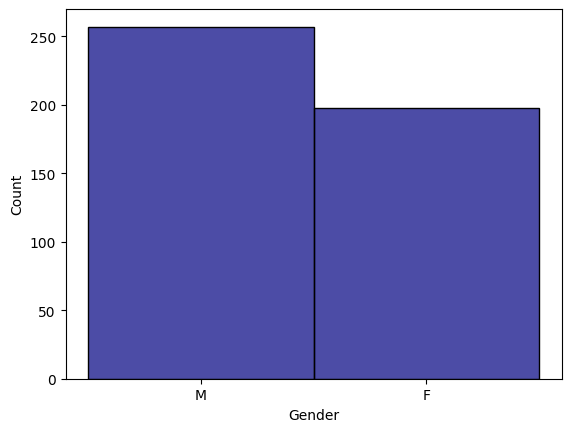

In [62]:
# Gender distribution
sns.histplot(df['Gender'],kde = False, color = 'navy', alpha = 0.7)

<Axes: xlabel='BloodPressure', ylabel='Count'>

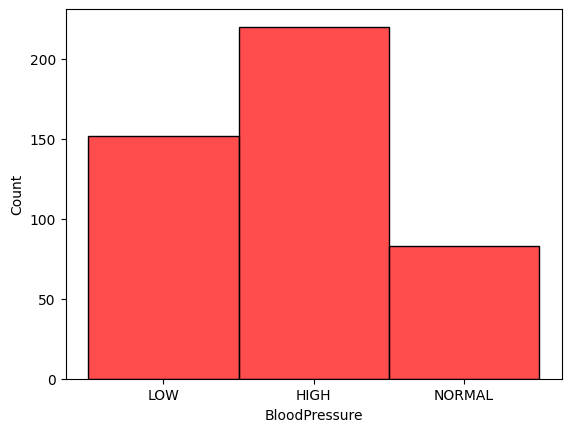

In [63]:
# Blood Pressure distribution
sns.histplot(df['BloodPressure'],kde = False, color = 'red', alpha = 0.7)

<Axes: xlabel='Cholestrol', ylabel='Count'>

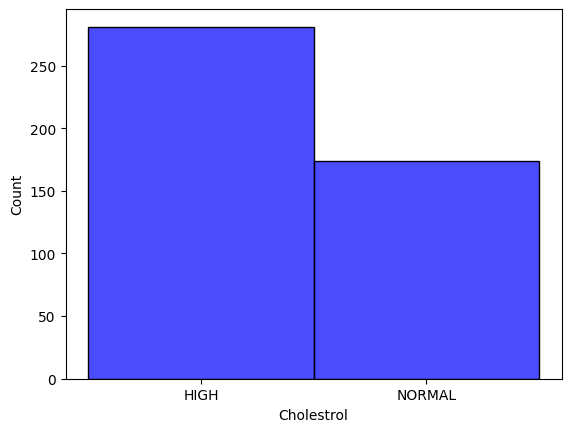

In [64]:
# Cholestrol distribution
sns.histplot(df['Cholestrol'],kde = False, color = 'blue', alpha = 0.7)

<Axes: xlabel='Class', ylabel='Count'>

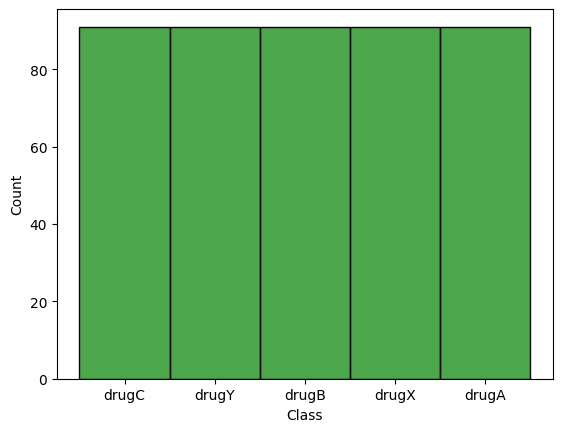

In [65]:
# Target distribution
sns.histplot(df['Class'],kde = False, color = 'green', alpha = 0.7)

In [66]:
# Na_to_K distribution
df['Na_to_K'].skew()

np.float64(2.0245413886516355)

### **Cleaning**

In [67]:
# null values
df.isna().sum()

Age              0
Gender           0
BloodPressure    0
Cholestrol       0
Na_to_K          0
Class            0
dtype: int64

In [68]:
# duplicates
df.duplicated().sum()

np.int64(1)

In [69]:
# outliers
numeric_cols = ['Age', 'Na_to_K']

q1 = df[numeric_cols].quantile(0.25)
q3 = df[numeric_cols].quantile(0.75)

iqr = q3 - q1

lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = (df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)

print(outliers.sum())

Age         0
Na_to_K    47
dtype: int64


In [70]:
# Remove rows containing outliers
df = df[~outliers.any(axis=1)]
print(df.shape)

(408, 6)


In [71]:
df.columns.to_list()

['Age', 'Gender', 'BloodPressure', 'Cholestrol', 'Na_to_K', 'Class']

### **Transformation and Pipelines**

### **Recommended Transformation/Scaling Methods per Column**

| Column  | Recommended Method (in order)   |
| :------ | :------------------------------ |
| `Age`  | StandardScaler           |
| `Na_to_K`  | StandardScaler           |
| `Gender`  | OneHotEncoding           |
| `BloodPressure`  | OrdinalEncoding           |
| `Cholestrol`  | OrdinalEncoding           |



In [72]:
df['Cholestrol'].unique()

array(['HIGH', 'NORMAL'], dtype=object)

In [73]:
df['BloodPressure'].unique()

array(['LOW', 'HIGH', 'NORMAL'], dtype=object)

In [74]:
# trasformation and scaling
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,FunctionTransformer, OneHotEncoder, OrdinalEncoder

scaling = ['Age','Na_to_K']
ordinal_bp = ['BloodPressure']
ordinal_chol = ['Cholestrol']
one_hot = ['Gender']



feature_cols = scaling + ordinal_bp + one_hot + ordinal_chol
x = df[feature_cols]
y = df['Class']

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)

In [75]:
# Individual Pipeline Setup

# scaling
scaling_pipeline = Pipeline(
    steps = [
        ('scale',StandardScaler())
    ])

ordinal_pipeline_bp = Pipeline(
    steps = [
        ('encode',OrdinalEncoder(categories=[['LOW', 'NORMAL', 'HIGH']]))
    ])

ordinal_pipeline_chol = Pipeline(
    steps = [
        ('encode',OrdinalEncoder(categories=[['NORMAL', 'HIGH']]))
    ])

one_hot_pipeline = Pipeline(
    steps = [
        ('ecoder',OneHotEncoder(handle_unknown='ignore'))
    ])

In [76]:
# Preprocessing Pipeline
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(transformers = [
    ('Scaled Pipeline',scaling_pipeline, scaling),
    ('Ordianal BP Pipeline',ordinal_pipeline_bp, ordinal_bp),
    ('Ordianal CHOL Pipeline',ordinal_pipeline_chol, ordinal_chol),
    ('One Hot Pipeline',one_hot_pipeline, one_hot)
])

preprocessor

ColumnTransformer(transformers=[('Scaled Pipeline',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['Age', 'Na_to_K']),
                                ('Ordianal BP Pipeline',
                                 Pipeline(steps=[('encode',
                                                  OrdinalEncoder(categories=[['LOW',
                                                                              'NORMAL',
                                                                              'HIGH']]))]),
                                 ['BloodPressure']),
                                ('Ordianal CHOL Pipeline',
                                 Pipeline(steps=[('encode',
                                                  OrdinalEncoder(categories=[['NORMAL',
                                                                              'HIGH']]))]),
                                 ['Cholestrol']),
                                ('One Hot Pipeline',
                                 Pipeline(steps=[('ecoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['Gender'])])

In [77]:
# model training
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import GridSearchCV

model = Pipeline(
    steps = [
        ('preprocess', preprocessor),
        ('classify', DecisionTreeClassifier(random_state=42))
    ])

# hyper-parameter tuning
param_grid = {
    'classify__criterion': ['gini', 'entropy', 'log_loss'],
    'classify__max_depth': [3, 5, 7, 10, 15, None],
    'classify__min_samples_split': [2, 5, 10],
    'classify__min_samples_leaf': [1, 2, 4],
    'classify__max_features': [None, 'sqrt', 'log2']
}

grid = GridSearchCV(
    estimator = model,
    cv = 5,
    param_grid = param_grid,
    n_jobs = -1,
    scoring = 'accuracy',
    verbose = 1
)

grid.fit(x_train, y_train)


# best stuff
print('best hyperparameters : ',grid.best_params_)
print('best score : ',grid.best_score_)
print('best estimator : ',grid.best_estimator_)

Fitting 5 folds for each of 486 candidates, totalling 2430 fits
best hyperparameters :  {'classify__criterion': 'entropy', 'classify__max_depth': 5, 'classify__max_features': None, 'classify__min_samples_leaf': 1, 'classify__min_samples_split': 2}
best score :  1.0
best estimator :  Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('Scaled Pipeline',
                                                  Pipeline(steps=[('scale',
                                                                   StandardScaler())]),
                                                  ['Age', 'Na_to_K']),
                                                 ('Ordianal BP Pipeline',
                                                  Pipeline(steps=[('encode',
                                                                   OrdinalEncoder(categories=[['LOW',
                                                                                               'NORMAL',
                       

accuracy_score :  1.0



<Axes: >

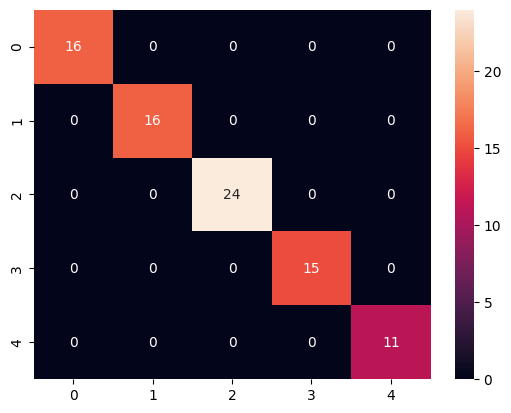

In [78]:
# decision tree tuned
dt_best = grid.best_estimator_

y_pred_best = dt_best.predict(x_test)
print('accuracy_score : ',accuracy_score(y_test, y_pred_best))
print() 
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True)

accuracy_score :  1.0



<Axes: >

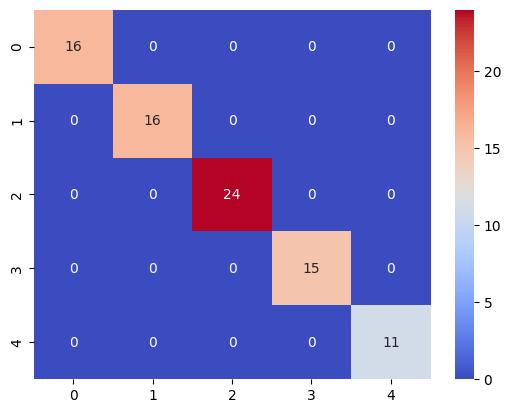

In [79]:
# decision Tree default
model_default = Pipeline(
    steps = [
        ('preprocess',preprocessor),
        ('classify',DecisionTreeClassifier())
    ])

model_default.fit(x_train, y_train)
y_pred = model_default.predict(x_test)

print('accuracy_score : ',accuracy_score(y_test, y_pred))
print() 
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, cmap = 'coolwarm')

# ✅ Both Performs Equally Well